===== BASIC INFO =====

Shape: (400, 26)

Data Types:
 id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

Missing Values:
 id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr              

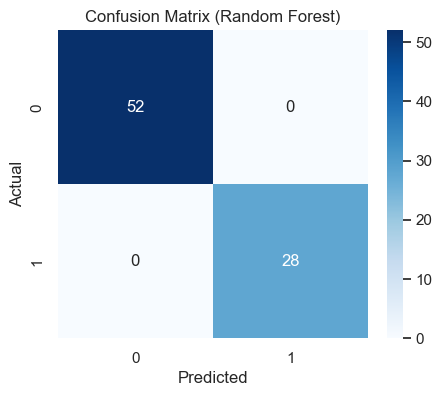

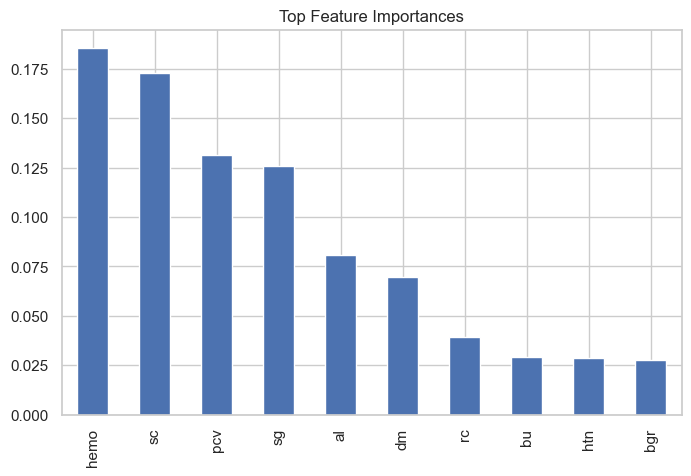


Top Features:
 hemo    0.185428
sc      0.172979
pcv     0.131465
sg      0.125639
al      0.080776
dm      0.069390
rc      0.039447
bu      0.029176
htn     0.028589
bgr     0.027461
dtype: float64


In [3]:
# 0. IMPORTS & SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv("kidney_disease 2.csv")


# 1. BASIC DATA INSPECTION

print("===== BASIC INFO =====")

print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())


# 2. CLEAN TARGET VARIABLE

# Fix inconsistent labels
df['classification'] = df['classification'].str.strip()

print("\nTarget Distribution:\n", df['classification'].value_counts())


# 3. HANDLE MISSING VALUES

# Separate numeric & categorical
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Fill numeric with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# 4. ENCODE CATEGORICAL VARIABLES

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


# 5. FEATURE & TARGET SPLIT

X = df.drop(columns=["classification", "id"])
y = df["classification"]


# 6. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# 7. SCALING (for LR only)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================================
# 8. MODELS
# =========================================

# ---------- 8.1 Dummy Classifier ----------
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("\nDummy Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))


# ---------- 8.2 Logistic Regression ----------
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\nLogistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


# ---------- 8.3 Random Forest (MAIN MODEL) ----------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



# 9. CONFUSION MATRIX

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 10. FEATURE IMPORTANCE

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.head(10).plot(kind="bar")
plt.title("Top Feature Importances")
plt.show()

print("\nTop Features:\n", importances.head(10))